In [2]:
from pdb2mrc import PDB2MRC
from plotting_tools import *
import torch

%load_ext autoreload
%autoreload 2

In [3]:
fftn = lambda array: torch.fft.fftshift(torch.fft.fftn(torch.fft.ifftshift(array)))
ifftn = lambda array: torch.fft.fftshift(torch.fft.ifftn(torch.fft.ifftshift(array)))

## Instantiate class

In [4]:
pdb_code = '1A6M'
pm = PDB2MRC(pdb_code)

## Download PDB file

In [5]:
pm.fetch_pdb()

PDB file saved to: ./pdb-data/1A6M.cif


## Compute particle potential

In [39]:
pm.build_particle(n=256, dx=1)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  5.75it/s]


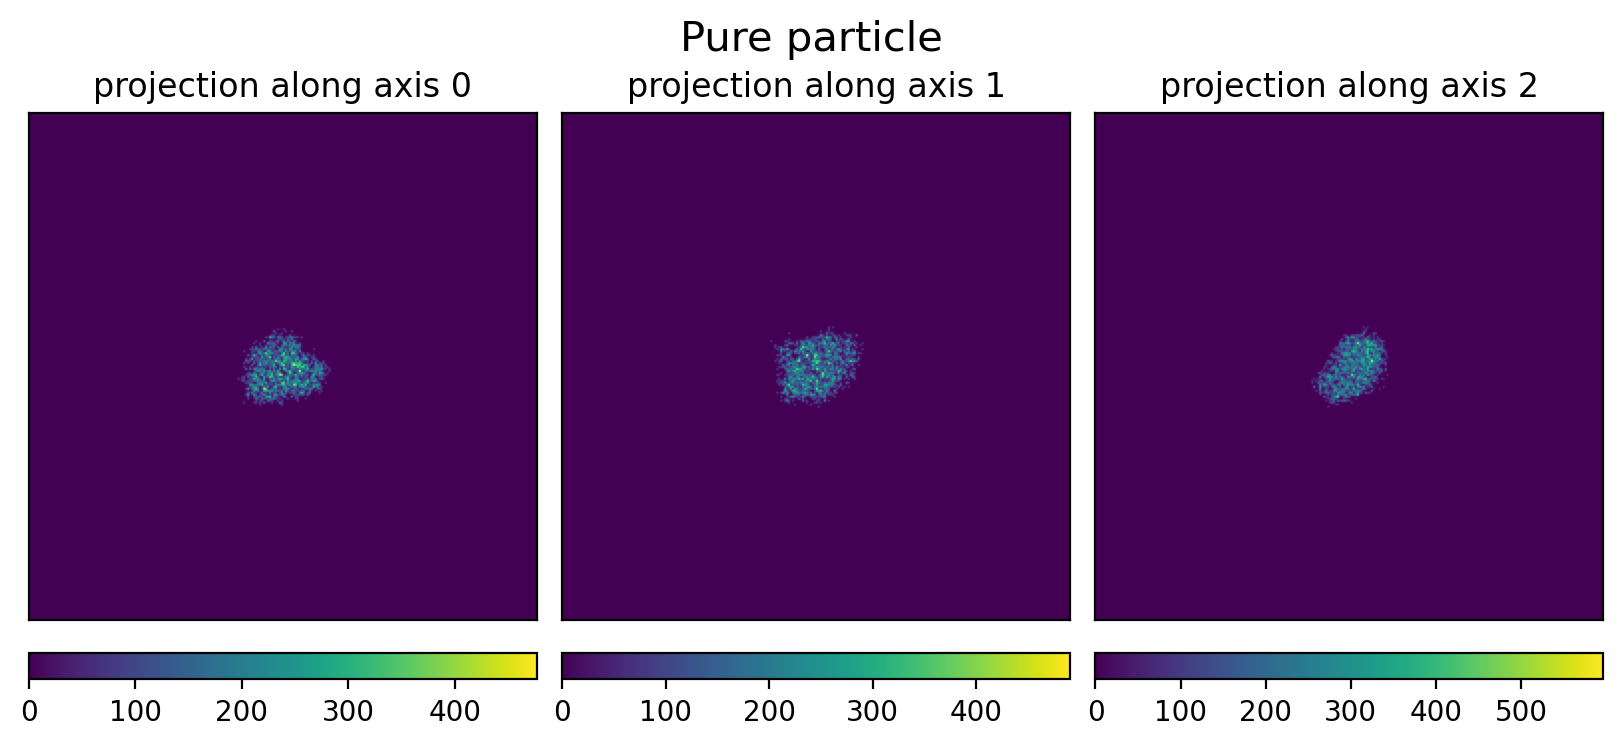

In [40]:
plot3d(pm.particle, title='Pure particle')

## Solvate
Note: Time taken increases exponentially with larger box sizes.
- 256A x 256A x 256A takes 1.5 hours.
- 150A x 150A x 150A takes 3 minutes.
- 100A x 100A x 100A takes 20 seconds.

In [37]:
pm.solvate()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [1:18:21<00:00, 940.31s/it]


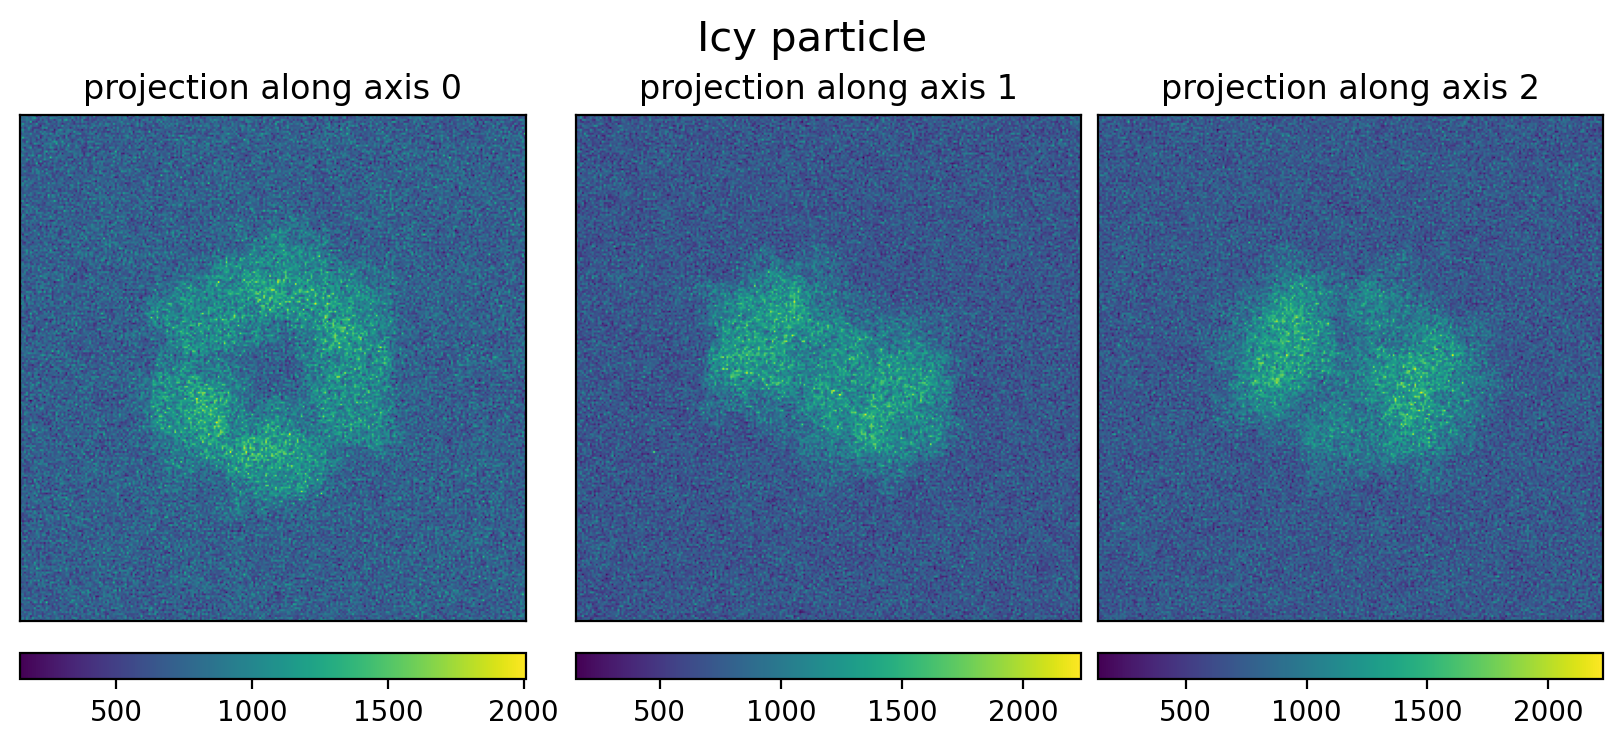

In [38]:
plot3d(pm.icy_particle, title='Icy particle')

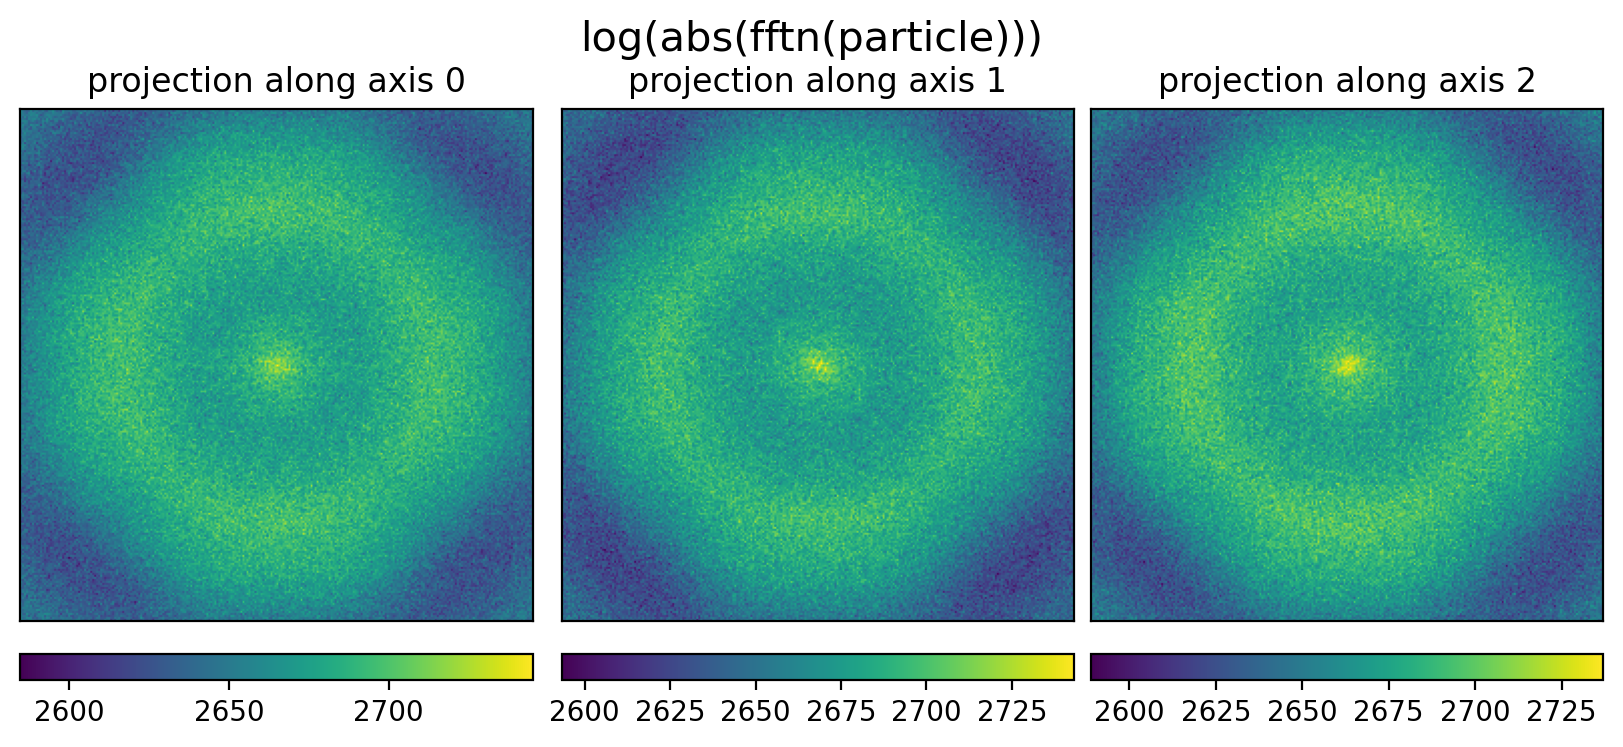

In [39]:
plot3d(torch.log(torch.abs(fftn(pm.icy_particle))), title='log(abs(fftn(particle)))')